# Seasonal Agriculture Performance Analysis

**Internship Major Project — Data Analytics**

---

## Introduction

Agriculture in India is deeply shaped by the three principal cropping seasons — **Kharif**, **Rabi**, and **Zaid** — each defined by distinct rainfall patterns, temperature ranges, and crop choices. This project analyzes a farm-level dataset spanning eight states, ten districts, eight crops, and four irrigation methods to understand how agricultural performance — yield, resource usage, environmental conditions, and economic outcomes — changes across these seasons.

The analysis follows a complete data analytics workflow: understanding the raw data, cleaning and preparing it, exploring it visually, and finally applying statistical tests to confirm whether the seasonal patterns observed are meaningful or simply due to chance.

## Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability, and market conditions. As a result, agricultural performance may differ from one season to another.

However, raw agricultural data does not by itself explain how performance changes across seasons or what patterns exist within different seasonal conditions.

**The problem addressed in this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships, and variations within the available data.**

## Objectives

1. Explore and understand the structure and content of the dataset.
2. Clean and prepare the data for reliable analysis.
3. Examine how agricultural yield and production vary across seasons.
4. Identify seasonal patterns in environmental conditions (rainfall, temperature, humidity, sunlight, soil health).
5. Investigate how resource usage (fertilizer, pesticide, water, irrigation method) varies by season.
6. Analyze economic performance (cost, revenue, profit) across seasons.
7. Compare performance across states/regions and crops.
8. Study correlations and relationships between environmental factors, resource usage, and yield.
9. Apply appropriate statistical tests to validate observed seasonal differences.
10. Derive evidence-based insights and practical, data-driven recommendations.

## Dataset Overview

The dataset (`seasonal_agriculture_performance_dataset.csv`) contains **4,000 farm-level records** across **28 columns**, covering:

| Category | Columns |
|---|---|
| **Identifiers / Location** | `Farm_ID`, `State`, `District` |
| **Crop & Season** | `Crop`, `Season` |
| **Farm & Environment** | `Farm_Area_Hectares`, `Rainfall_mm`, `Avg_Temperature_C`, `Humidity_pct`, `Sunlight_Hours_Day`, `Soil_pH`, `Soil_Moisture_pct`, `Disease_Pest_Risk_pct` |
| **Soil Nutrients** | `Nitrogen_kg_ha`, `Phosphorus_kg_ha`, `Potassium_kg_ha` |
| **Resource Usage** | `Irrigation_Method`, `Fertilizer_kg_ha`, `Pesticide_Litre_ha`, `Water_Used_m3`, `Water_Efficiency_t_per_1000m3` |
| **Production** | `Seed_Quality_Score`, `Yield_Tonnes_Ha`, `Production_Tonnes` |
| **Economics** | `Market_Price_INR_Tonne`, `Total_Cost_INR`, `Revenue_INR`, `Profit_INR` |

The dataset is explored below without assuming any column meaning beyond what is confirmed programmatically — only columns that genuinely exist are used throughout this notebook.

In [6]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats

# Display / plot settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
df = pd.read_csv('seasonal_agriculture_performance_dataset (2).csv')
print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Dataset loaded successfully with 4000 rows and 28 columns.


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## Data Understanding

Before any cleaning or analysis, we inspect the dataset's structure: its shape, column names, data types, sample rows, descriptive statistics, and the unique values of key categorical fields.

In [8]:
print("Shape of dataset (rows, columns):", df.shape)

Shape of dataset (rows, columns): (4000, 28)


In [9]:
print("Column names:\n")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

Column names:

 1. Farm_ID
 2. State
 3. District
 4. Crop
 5. Season
 6. Farm_Area_Hectares
 7. Rainfall_mm
 8. Avg_Temperature_C
 9. Humidity_pct
10. Sunlight_Hours_Day
11. Soil_pH
12. Soil_Moisture_pct
13. Nitrogen_kg_ha
14. Phosphorus_kg_ha
15. Potassium_kg_ha
16. Irrigation_Method
17. Fertilizer_kg_ha
18. Pesticide_Litre_ha
19. Seed_Quality_Score
20. Yield_Tonnes_Ha
21. Production_Tonnes
22. Market_Price_INR_Tonne
23. Total_Cost_INR
24. Revenue_INR
25. Profit_INR
26. Water_Used_m3
27. Water_Efficiency_t_per_1000m3
28. Disease_Pest_Risk_pct


In [10]:
df.dtypes.to_frame(name='Data Type')

,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [11]:
print("First 5 rows:")
df.head()

First 5 rows:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [12]:
print("Last 5 rows:")
df.tail()

Last 5 rows:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,7.97,27.3,104.3,44.8,94.0,Drip,271.1,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,6.57,33.7,127.8,44.9,91.3,Drip,176.6,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,7.25,21.1,126.7,59.9,148.0,Drip,234.7,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,6.11,30.5,107.5,20.7,91.0,Sprinkler,329.7,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,6.16,35.7,137.1,92.6,145.5,Sprinkler,205.9,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [14]:
print("Unique value counts for key categorical columns:\n")
for col in ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']:
    print(f"{col} -> {df[col].nunique()} unique values: {sorted(df[col].unique())}")
    print()

Unique value counts for key categorical columns:

State -> 8 unique values: ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']

District -> 10 unique values: ['Erode', 'Guntur', 'Indore', 'Krishna', 'Ludhiana', 'Nalgonda', 'Nashik', 'Raichur', 'Rajkot', 'Warangal']

Crop -> 8 unique values: ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']

Season -> 3 unique values: ['Kharif', 'Rabi', 'Zaid']

Irrigation_Method -> 4 unique values: ['Drip', 'Flood', 'Rainfed', 'Sprinkler']



In [15]:
print("Number of unique Farm_IDs:", df['Farm_ID'].nunique(), "out of", len(df), "rows")

Number of unique Farm_IDs: 4000 out of 4000 rows


## Data Cleaning & Preprocessing

This section checks and resolves:
- Missing values
- Duplicate records
- Incorrect data types
- Invalid / inconsistent values
- Outliers (examined per crop, since crops operate on very different yield scales — e.g. Sugarcane is harvested in tens of tonnes/hectare while grains are harvested in single digits)

In [16]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

,Missing Count,Missing %
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


Only three numeric columns contain missing values, and each is under **1.5%** of the dataset. Since agronomic values (rainfall, soil moisture, yield) vary meaningfully by **Crop and Season**, missing values are imputed using the **median of the same Crop-Season group**, which is far more accurate than a single dataset-wide median. Any group too small to have its own median falls back to the overall column median.

In [17]:
cols_with_na = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for col in cols_with_na:
    before = df[col].isnull().sum()
    df[col] = df.groupby(['Season', 'Crop'])[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median())  # safety fallback
    after = df[col].isnull().sum()
    print(f"{col}: {before} missing -> {after} missing (imputed using Season+Crop group median)")

print("\nTotal missing values remaining in dataset:", df.isnull().sum().sum())

Rainfall_mm: 48 missing -> 0 missing (imputed using Season+Crop group median)
Soil_Moisture_pct: 40 missing -> 0 missing (imputed using Season+Crop group median)
Yield_Tonnes_Ha: 32 missing -> 0 missing (imputed using Season+Crop group median)

Total missing values remaining in dataset: 0


In [18]:
duplicate_rows = df.duplicated().sum()
duplicate_farm_ids = df['Farm_ID'].duplicated().sum()
print(f"Fully duplicated rows: {duplicate_rows}")
print(f"Duplicated Farm_ID values: {duplicate_farm_ids}")
print("\nNo duplicate records found — no rows need to be dropped." if duplicate_rows == 0 else "Duplicates found and will be removed.")

if duplicate_rows > 0:
    df = df.drop_duplicates()
    print("New shape after dropping duplicates:", df.shape)

Fully duplicated rows: 0
Duplicated Farm_ID values: 0

No duplicate records found — no rows need to be dropped.


**Incorrect data types:** All numeric columns are already stored as `int`/`float`, which is correct. The categorical columns (`State`, `District`, `Crop`, `Season`, `Irrigation_Method`) are stored as generic objects/strings; converting them to pandas `category` dtype is more memory-efficient and semantically correct for repeated grouping operations used throughout this notebook.

In [19]:
categorical_cols = ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']
for col in categorical_cols:
    df[col] = df[col].astype('category')

print("Updated data types for categorical columns:")
df[categorical_cols].dtypes

Updated data types for categorical columns:


State                category
District             category
Crop                 category
Season               category
Irrigation_Method    category
dtype: object

**Invalid / inconsistent values:** Physically implausible values (e.g. negative rainfall, negative yield, negative farm area, humidity outside 0–100%) are checked below. `Profit_INR` is expected to legitimately go negative (a loss-making farm), so it is excluded from this "must be non-negative" check.

In [20]:
checks = {
    'Farm_Area_Hectares': (df['Farm_Area_Hectares'] <= 0).sum(),
    'Rainfall_mm': (df['Rainfall_mm'] < 0).sum(),
    'Avg_Temperature_C': (df['Avg_Temperature_C'] < -10).sum(),
    'Humidity_pct': ((df['Humidity_pct'] < 0) | (df['Humidity_pct'] > 100)).sum(),
    'Soil_pH': ((df['Soil_pH'] < 0) | (df['Soil_pH'] > 14)).sum(),
    'Yield_Tonnes_Ha': (df['Yield_Tonnes_Ha'] < 0).sum(),
    'Production_Tonnes': (df['Production_Tonnes'] < 0).sum(),
    'Total_Cost_INR': (df['Total_Cost_INR'] < 0).sum(),
    'Revenue_INR': (df['Revenue_INR'] < 0).sum(),
    'Water_Used_m3': (df['Water_Used_m3'] < 0).sum(),
}

result = pd.DataFrame.from_dict(checks, orient='index', columns=['Invalid Value Count'])
print(result)
print("\nAll checked columns contain zero physically invalid values — the dataset is internally consistent." 
      if result['Invalid Value Count'].sum() == 0 else "Some invalid values were found — review above.")

                    Invalid Value Count
Farm_Area_Hectares                    0
Rainfall_mm                           0
Avg_Temperature_C                     0
Humidity_pct                          0
Soil_pH                               0
Yield_Tonnes_Ha                       0
Production_Tonnes                     0
Total_Cost_INR                        0
Revenue_INR                           0
Water_Used_m3                         0

All checked columns contain zero physically invalid values — the dataset is internally consistent.


**Outliers:** Because Sugarcane's yield scale (tens of tonnes/hectare) is fundamentally different from grain and pulse crops (single digits), outliers are detected **within each crop** using the IQR method, rather than on the mixed-crop column directly — which would misclassify normal Sugarcane yields as outliers.

In [21]:
outlier_summary = []
for crop in df['Crop'].cat.categories:
    vals = df.loc[df['Crop'] == crop, 'Yield_Tonnes_Ha']
    q1, q3 = vals.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((vals < lower) | (vals > upper)).sum()
    outlier_summary.append([crop, len(vals), n_outliers, round(lower, 2), round(upper, 2)])

outlier_df = pd.DataFrame(outlier_summary, columns=['Crop', 'N', 'Yield Outliers', 'Lower Bound', 'Upper Bound'])
outlier_df

,Crop,N,Yield Outliers,Lower Bound,Upper Bound
0,Chilli,412,1,-0.89,3.90
1,Cotton,508,1,-0.28,2.73
2,Groundnut,424,0,-0.44,3.04
3,Maize,551,0,-0.88,6.36
4,Pulses,496,0,-0.44,2.25
5,Rice,690,0,-1.02,5.93
6,Sugarcane,305,0,-11.22,105.78
7,Wheat,614,0,-0.53,4.75


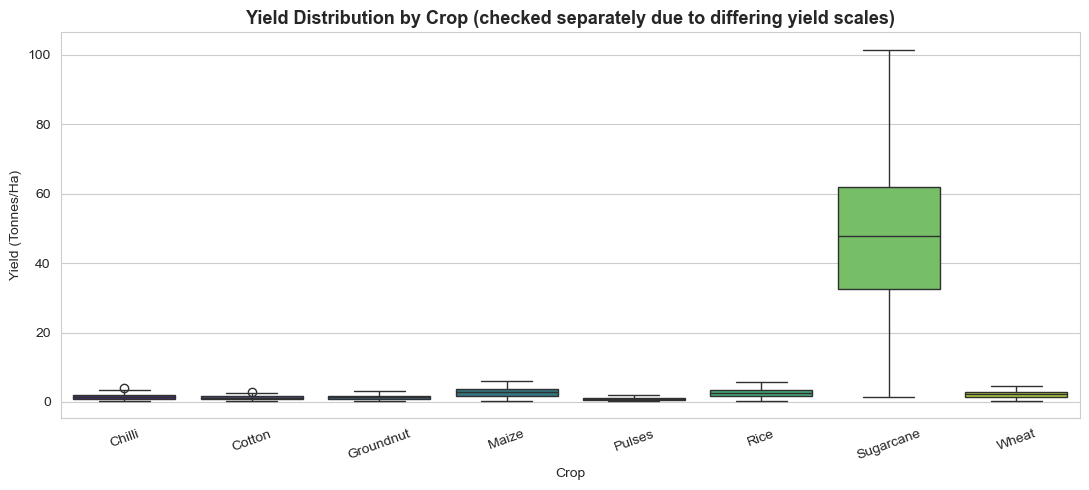

Interpretation: Per-crop IQR analysis shows almost no statistical outliers within any single crop (at most 1, in Cotton) — the wide overall range in Yield_Tonnes_Ha is explained by genuine crop-type differences (Sugarcane), not data errors. No values are removed.


In [22]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x='Crop', y='Yield_Tonnes_Ha', hue='Crop', palette='viridis', ax=ax, legend=False)
ax.set_title('Yield Distribution by Crop (checked separately due to differing yield scales)')
ax.set_ylabel('Yield (Tonnes/Ha)')
ax.set_xlabel('Crop')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print("Interpretation: Per-crop IQR analysis shows almost no statistical outliers within any single crop "
      "(at most 1, in Cotton) — the wide overall range in Yield_Tonnes_Ha is explained by genuine crop-type "
      "differences (Sugarcane), not data errors. No values are removed.")

## Exploratory Data Analysis (EDA)

This section examines the overall shape of the data — the balance of categorical groups and the distribution of key numeric variables — before narrowing into season-specific analysis.

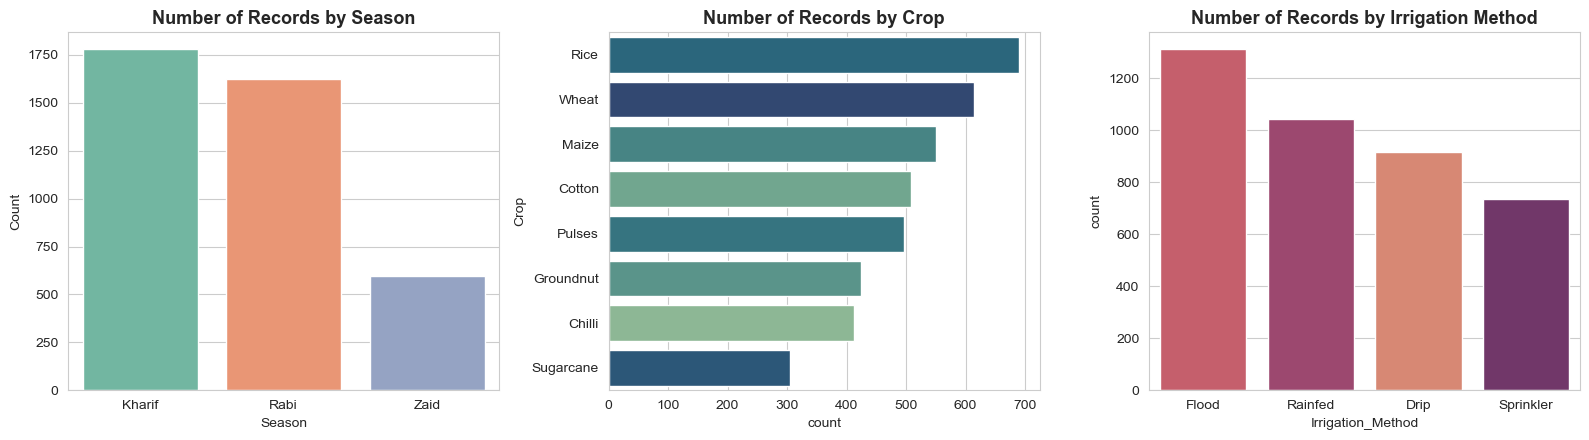

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.countplot(data=df, x='Season', hue='Season', order=['Kharif', 'Rabi', 'Zaid'],
              palette='Set2', ax=axes[0], legend=False)
axes[0].set_title('Number of Records by Season')
axes[0].set_ylabel('Count')

sns.countplot(data=df, y='Crop', hue='Crop', order=df['Crop'].value_counts().index,
              palette='crest', ax=axes[1], legend=False)
axes[1].set_title('Number of Records by Crop')

sns.countplot(data=df, x='Irrigation_Method', hue='Irrigation_Method',
              order=df['Irrigation_Method'].value_counts().index,
              palette='flare', ax=axes[2], legend=False)
axes[2].set_title('Number of Records by Irrigation Method')

plt.tight_layout()
plt.show()

print(df['Season'].value_counts())

**Interpretation:** Kharif has the most records (1,779), followed by Rabi (1,627) and Zaid (594) — Zaid is a shorter, less widely cultivated season in reality, and the dataset reflects that natural imbalance. Flood and Rainfed are the most common irrigation methods overall.

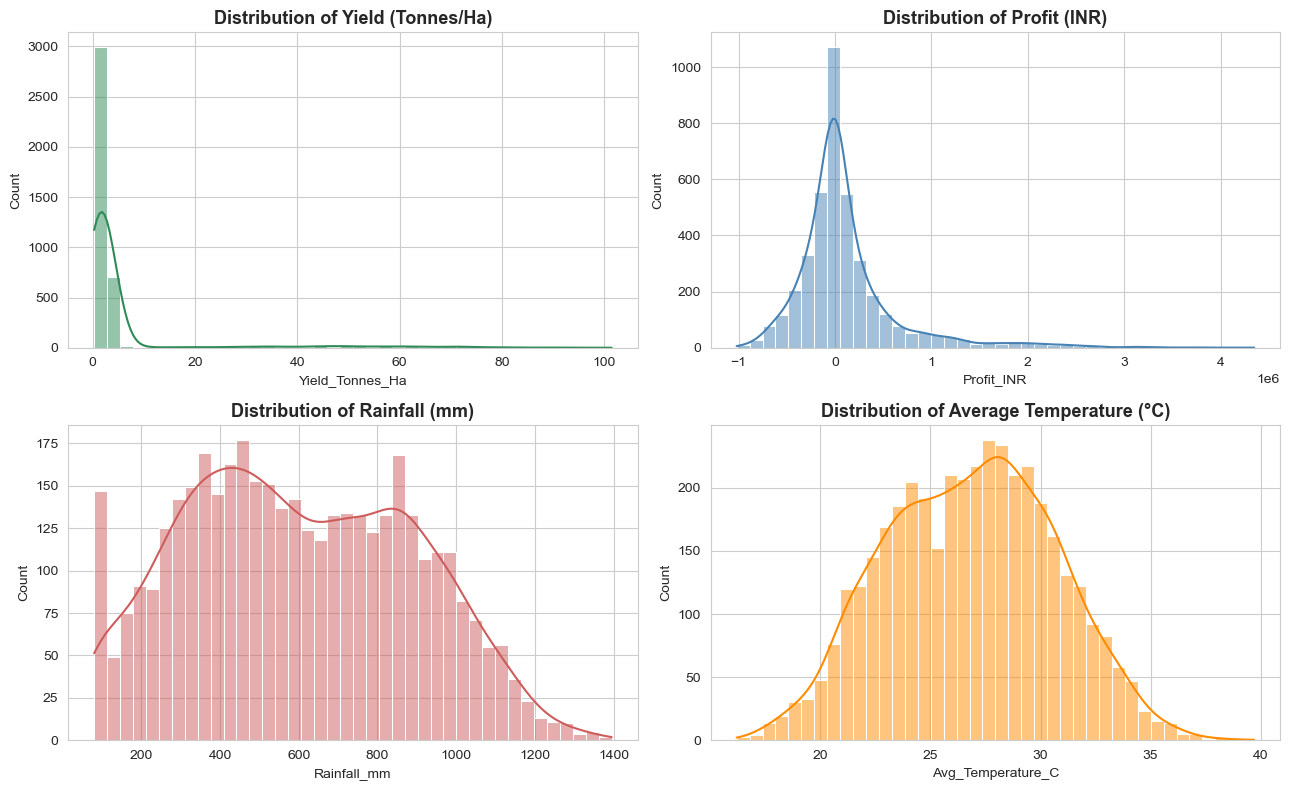

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.histplot(df['Yield_Tonnes_Ha'], bins=40, kde=True, ax=axes[0, 0], color='seagreen')
axes[0, 0].set_title('Distribution of Yield (Tonnes/Ha)')

sns.histplot(df['Profit_INR'], bins=40, kde=True, ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Distribution of Profit (INR)')

sns.histplot(df['Rainfall_mm'], bins=40, kde=True, ax=axes[1, 0], color='indianred')
axes[1, 0].set_title('Distribution of Rainfall (mm)')

sns.histplot(df['Avg_Temperature_C'], bins=40, kde=True, ax=axes[1, 1], color='darkorange')
axes[1, 1].set_title('Distribution of Average Temperature (\u00b0C)')

plt.tight_layout()
plt.show()

**Interpretation:** Yield is right-skewed (most farms cluster at low tonnes/ha with a long tail from Sugarcane). Profit is roughly centered near zero with wide spread on both sides — meaning a substantial share of farms operate at a loss. Rainfall is right-skewed while temperature is fairly symmetric around the mid-to-high 20s °C.

## Seasonal Agriculture Performance Analysis

The core question of this project: **how does agricultural performance — yield and production — vary across Kharif, Rabi, and Zaid?**

In [25]:
season_order = ['Kharif', 'Rabi', 'Zaid']

seasonal_perf = df.groupby('Season', observed=True)[['Yield_Tonnes_Ha', 'Production_Tonnes']].agg(['mean', 'median']).round(2)
seasonal_perf = seasonal_perf.reindex(season_order)
seasonal_perf

Yield_Tonnes_Ha        Production_Tonnes       
                  mean median              mean median
Season                                                
Kharif            5.63   1.95             46.31  13.24
Rabi              5.09   1.66             41.49  11.08
Zaid              4.64   1.45             38.89   9.97

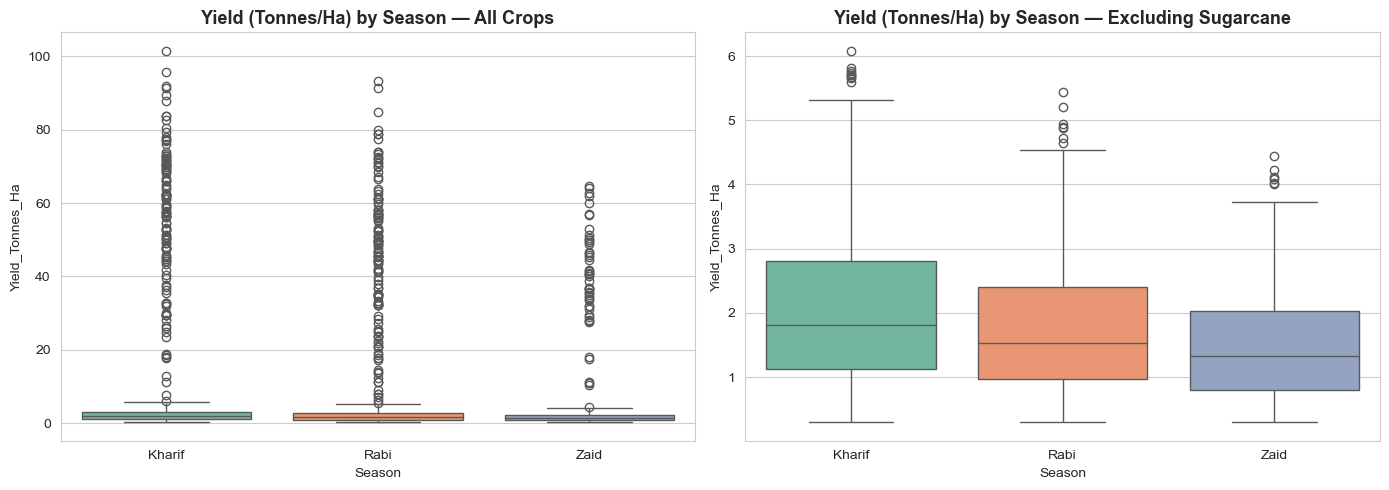

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', hue='Season', order=season_order,
            palette='Set2', ax=axes[0], legend=False)
axes[0].set_title('Yield (Tonnes/Ha) by Season — All Crops')

# Exclude Sugarcane for a clearer view of the grain/pulse/cash-crop majority
no_sugar = df[df['Crop'] != 'Sugarcane']
sns.boxplot(data=no_sugar, x='Season', y='Yield_Tonnes_Ha', hue='Season', order=season_order,
            palette='Set2', ax=axes[1], legend=False)
axes[1].set_title('Yield (Tonnes/Ha) by Season — Excluding Sugarcane')

plt.tight_layout()
plt.show()

**Interpretation:** Once Sugarcane (which is grown on a completely different yield scale) is set aside, a clear seasonal ordering emerges: **Kharif > Rabi > Zaid** in typical yield per hectare. This matches the seasonal median yields computed above (Kharif 1.95, Rabi 1.66, Zaid 1.45 tonnes/ha).

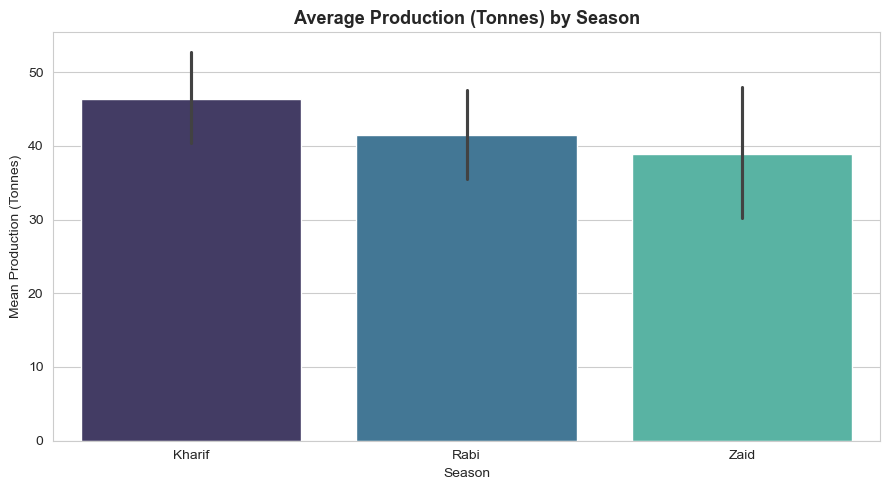

Season
Kharif    46.31
Rabi      41.49
Zaid      38.89
Name: Production_Tonnes, dtype: float64


In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df, x='Season', y='Production_Tonnes', hue='Season', order=season_order,
            estimator=np.mean, palette='mako', ax=ax, legend=False, errorbar=('ci', 95))
ax.set_title('Average Production (Tonnes) by Season')
ax.set_ylabel('Mean Production (Tonnes)')
plt.tight_layout()
plt.show()

print(df.groupby('Season', observed=True)['Production_Tonnes'].mean().reindex(season_order).round(2))

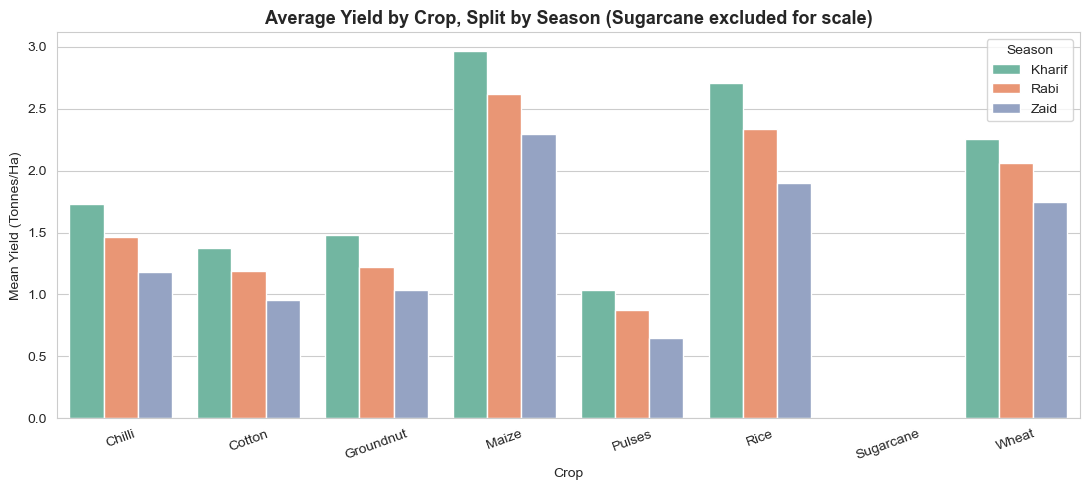

In [28]:
fig, ax = plt.subplots(figsize=(11, 5))
crop_season_yield = df[df['Crop'] != 'Sugarcane'].groupby(['Season', 'Crop'], observed=True)['Yield_Tonnes_Ha'].mean().reset_index()
sns.barplot(data=crop_season_yield, x='Crop', y='Yield_Tonnes_Ha', hue='Season', hue_order=season_order,
            palette='Set2', ax=ax)
ax.set_title('Average Yield by Crop, Split by Season (Sugarcane excluded for scale)')
ax.set_ylabel('Mean Yield (Tonnes/Ha)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Interpretation:** The Kharif-highest, Zaid-lowest yield pattern holds for **most individual crops**, not just in aggregate — Maize and Rice show the clearest seasonal drop-off, consistent with Zaid being a hot, water-constrained season for most non-irrigated crops.

## Environmental Condition Analysis

Rainfall, temperature, humidity, sunlight, and soil conditions define each season agronomically. This section checks whether the dataset's environmental readings behave the way real seasons would suggest.

In [29]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct']
env_by_season = df.groupby('Season', observed=True)[env_cols].mean().reindex(season_order).round(2)
env_by_season

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct
Season,,,,,,
Kharif,852.10,28.45,71.81,6.79,6.73,31.20
Rabi,435.95,23.49,57.89,7.59,6.67,24.05
Zaid,299.16,31.04,52.01,8.18,6.69,19.18


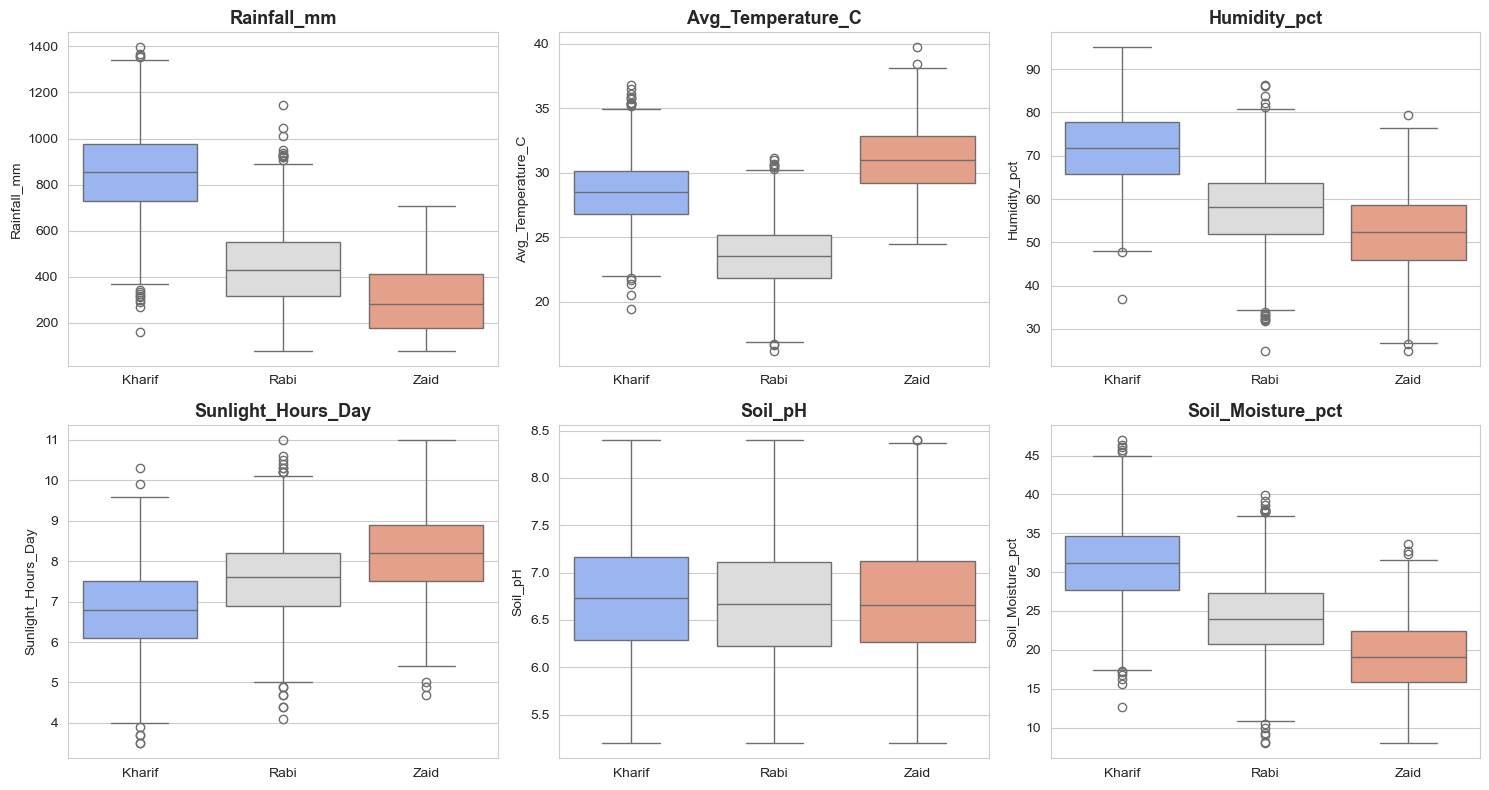

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(env_cols):
    sns.boxplot(data=df, x='Season', y=col, hue='Season', order=season_order,
                palette='coolwarm', ax=axes[i], legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

**Interpretation:** Kharif shows the highest rainfall and humidity (the monsoon season), Zaid shows the highest average temperature and lowest rainfall (the hot, dry summer season), and Rabi sits in between with the lowest temperatures — this matches real-world Indian seasonal agronomy and confirms the dataset's seasonal labels are agronomically sound. Soil pH and soil moisture are comparatively stable across seasons, with a mild moisture dip in Zaid.

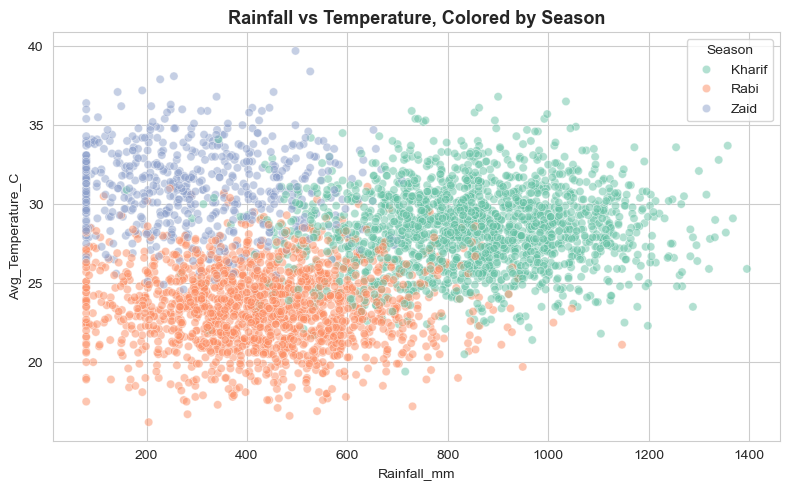

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='Rainfall_mm', y='Avg_Temperature_C', hue='Season', hue_order=season_order,
                 palette='Set2', alpha=0.5, ax=ax)
ax.set_title('Rainfall vs Temperature, Colored by Season')
plt.tight_layout()
plt.show()

**Interpretation:** The three seasons occupy visibly distinct regions of the rainfall-temperature space — Kharif clusters at high rainfall, Zaid clusters at high temperature/low rainfall, and Rabi occupies the cooler, moderate-rainfall region. This is a genuine environmental signature of each season in the data.

## Resource Usage Analysis

How much fertilizer, pesticide, and water each season's farms use — and which irrigation methods dominate — reveals how farming practice adapts to seasonal conditions.

In [32]:
resource_cols = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']
resource_by_season = df.groupby('Season', observed=True)[resource_cols].mean().reindex(season_order).round(2)
resource_by_season

,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,187.08,5.08,6102.20,5.89
Rabi,185.41,5.02,5846.99,5.19
Zaid,184.64,5.17,6419.89,4.41


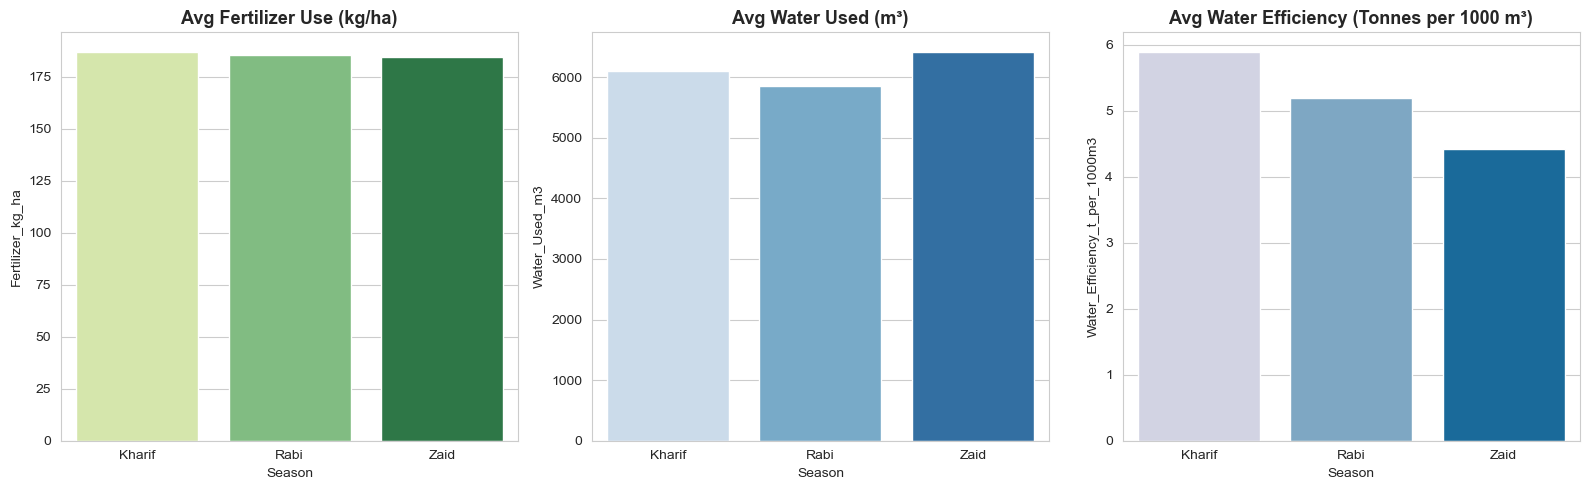

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=df, x='Season', y='Fertilizer_kg_ha', hue='Season', order=season_order,
            palette='YlGn', ax=axes[0], legend=False, errorbar=None)
axes[0].set_title('Avg Fertilizer Use (kg/ha)')

sns.barplot(data=df, x='Season', y='Water_Used_m3', hue='Season', order=season_order,
            palette='Blues', ax=axes[1], legend=False, errorbar=None)
axes[1].set_title('Avg Water Used (m\u00b3)')

sns.barplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', hue='Season', order=season_order,
            palette='PuBu', ax=axes[2], legend=False, errorbar=None)
axes[2].set_title('Avg Water Efficiency (Tonnes per 1000 m\u00b3)')

plt.tight_layout()
plt.show()

**Interpretation:** Zaid farms use noticeably more water on average despite the season's lower rainfall — a sign that Zaid cultivation leans more heavily on irrigation to compensate for the dry, hot conditions. Fertilizer use is comparatively steady across seasons, and water efficiency (tonnes of output per 1000 m³ used) is lowest in Zaid, meaning the extra water use in that season doesn't translate into proportionally higher output.

In [34]:
irrigation_ct = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index').mul(100).round(1)
irrigation_ct = irrigation_ct.reindex(season_order)
irrigation_ct

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2


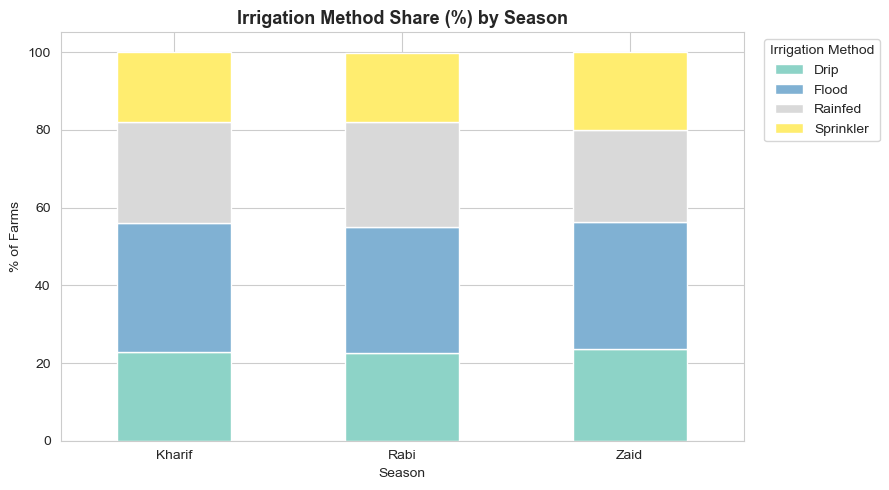

In [35]:
fig, ax = plt.subplots(figsize=(9, 5))
irrigation_ct.plot(kind='bar', stacked=True, colormap='Set3', ax=ax)
ax.set_title('Irrigation Method Share (%) by Season')
ax.set_ylabel('% of Farms')
ax.legend(title='Irrigation Method', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** The irrigation method mix is remarkably similar across all three seasons — Flood irrigation is consistently the most common method (~33%), followed by Rainfed (~27%), Drip (~24%) and Sprinkler (~17%) in every season. This is examined statistically later in the Statistical Analysis section.

## Economic Performance Analysis

Yield alone does not determine farm success — market prices, costs, and resulting profit matter just as much. This section checks whether seasonal yield advantages translate into seasonal economic advantages.

In [36]:
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100

econ_cols = ['Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Market_Price_INR_Tonne', 'Profit_Margin_pct']
econ_by_season = df.groupby('Season', observed=True)[econ_cols].median().reindex(season_order).round(2)
econ_by_season

,Total_Cost_INR,Revenue_INR,Profit_INR,Market_Price_INR_Tonne,Profit_Margin_pct
Season,,,,,
Kharif,524840.0,520196.0,38808.0,25793.0,11.09
Rabi,506733.0,438156.0,-3187.0,26041.0,-1.34
Zaid,534833.0,373700.5,-62144.0,25749.5,-24.59


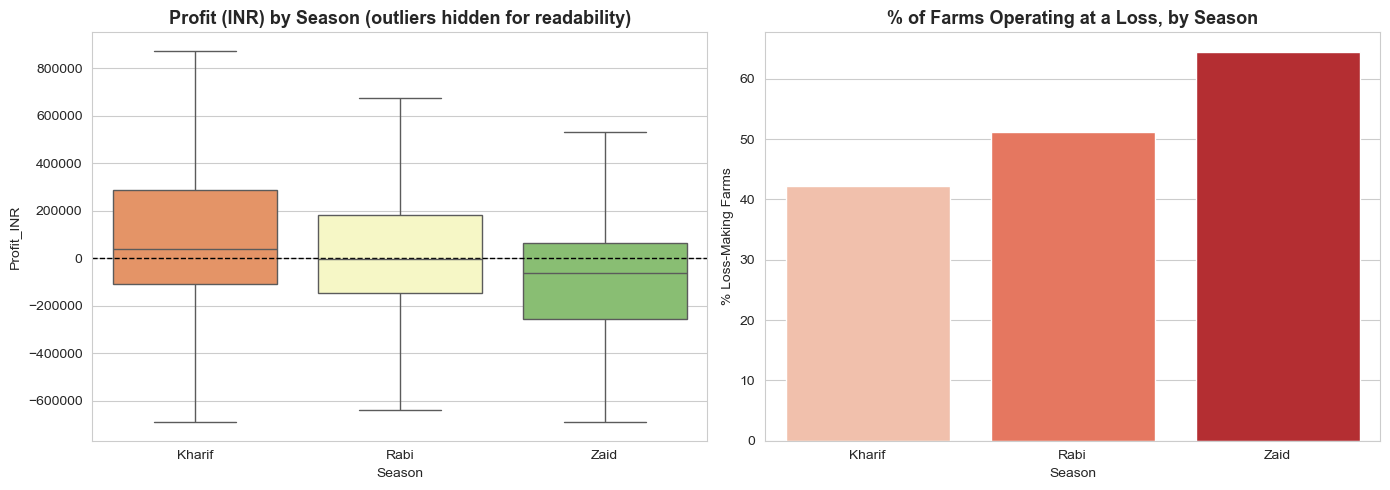

Median Profit (INR) by season:
Season
Kharif    38808.0
Rabi      -3187.0
Zaid     -62144.0
Name: Profit_INR, dtype: float64

% of farms with negative profit, by season:
Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
Name: Profit_INR, dtype: float64


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Season', y='Profit_INR', hue='Season', order=season_order,
            palette='RdYlGn', ax=axes[0], legend=False, showfliers=False)
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Profit (INR) by Season (outliers hidden for readability)')

loss_pct = df.groupby('Season', observed=True)['Profit_INR'].apply(lambda x: (x < 0).mean() * 100).reindex(season_order)
sns.barplot(x=loss_pct.index, y=loss_pct.values, hue=loss_pct.index, order=season_order,
            palette='Reds', ax=axes[1], legend=False)
axes[1].set_title('% of Farms Operating at a Loss, by Season')
axes[1].set_ylabel('% Loss-Making Farms')

plt.tight_layout()
plt.show()

print("Median Profit (INR) by season:")
print(df.groupby('Season', observed=True)['Profit_INR'].median().reindex(season_order))
print("\n% of farms with negative profit, by season:")
print(loss_pct.round(1))

**Interpretation:** Economic performance mirrors the yield pattern: **Kharif is the only season with a positive median profit** (~₹38,800), while both Rabi and Zaid have **negative median profit**. Loss rates climb sharply from Kharif (42.2%) to Rabi (51.1%) to Zaid (64.5%) — meaning nearly two-thirds of Zaid farms in this dataset operate at a loss. Zaid's higher water usage (previous section) combined with lower yield appears to erode profitability rather than compensate for it.

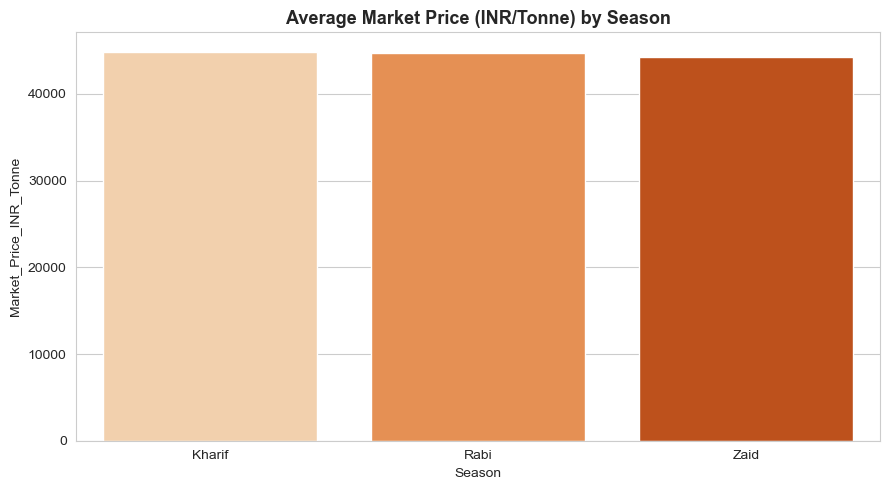

Season
Kharif    44851.0
Rabi      44748.0
Zaid      44212.0
Name: Market_Price_INR_Tonne, dtype: float64


In [38]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df, x='Season', y='Market_Price_INR_Tonne', hue='Season', order=season_order,
            palette='Oranges', ax=ax, legend=False, errorbar=None)
ax.set_title('Average Market Price (INR/Tonne) by Season')
plt.tight_layout()
plt.show()

print(df.groupby('Season', observed=True)['Market_Price_INR_Tonne'].mean().reindex(season_order).round(0))

**Interpretation:** Market prices do not vary dramatically by season, which means the profit gap between seasons is driven primarily by **yield and cost differences**, not by farmers in different seasons selling at different price points.

## Regional / Category Comparison

Since the dataset spans eight states, this section checks whether the Kharif > Rabi > Zaid seasonal pattern holds consistently everywhere, or whether some states behave differently.

In [39]:
state_season_yield = df[df['Crop'] != 'Sugarcane'].pivot_table(
    index='State', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean', observed=True
)[season_order].round(2)
state_season_yield

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,2.12,1.52,1.53
Gujarat,1.83,1.76,1.57
Karnataka,2.07,1.81,1.30
Madhya Pradesh,2.00,1.65,1.38
Maharashtra,2.06,1.74,1.51
Punjab,1.99,1.82,1.35
Tamil Nadu,1.91,1.86,1.43
Telangana,2.13,1.86,1.60


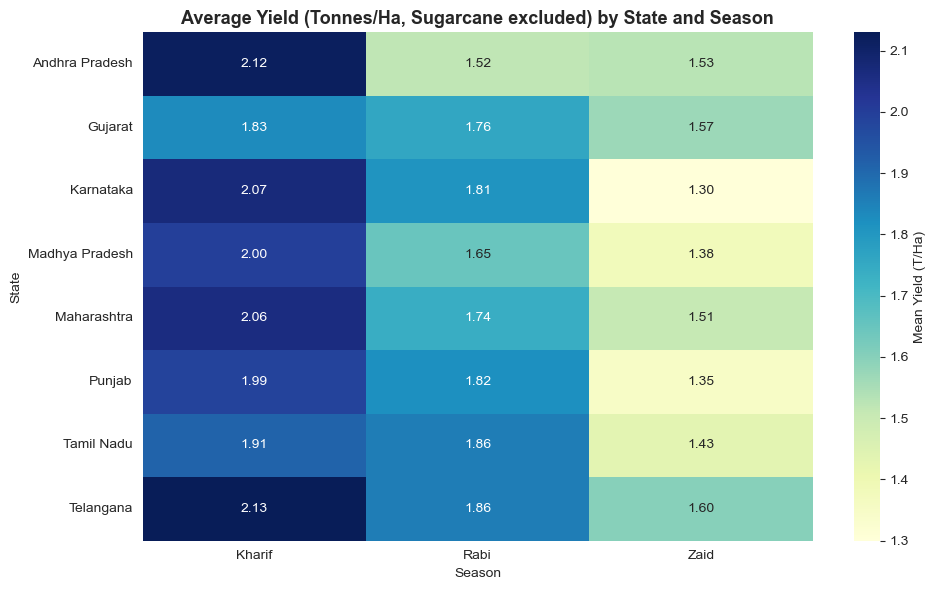

Number of states (out of 8) where Kharif yield exceeds Zaid yield: 8


In [40]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(state_season_yield, annot=True, fmt='.2f', cmap='YlGnBu', ax=ax, cbar_kws={'label': 'Mean Yield (T/Ha)'})
ax.set_title('Average Yield (Tonnes/Ha, Sugarcane excluded) by State and Season')
plt.tight_layout()
plt.show()

kharif_best = (state_season_yield['Kharif'] > state_season_yield['Zaid']).sum()
print(f"Number of states (out of {len(state_season_yield)}) where Kharif yield exceeds Zaid yield:", kharif_best)

**Interpretation:** The Kharif-highest / Zaid-lowest yield pattern holds in nearly every state, confirming that the seasonal effect is a broad, dataset-wide pattern rather than being driven by one or two regions.

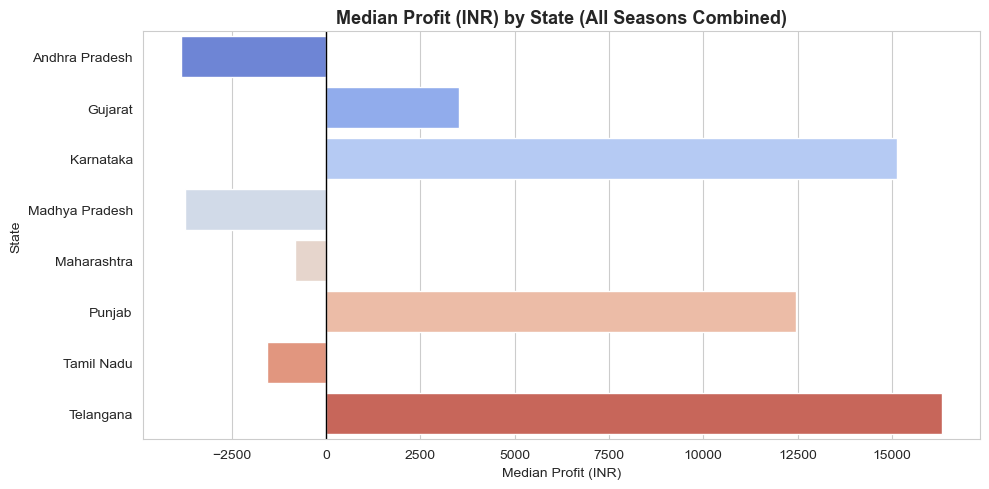

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))
state_profit = df.groupby('State', observed=True)['Profit_INR'].median().sort_values(ascending=False)
sns.barplot(x=state_profit.values, y=state_profit.index, hue=state_profit.index, palette='coolwarm', ax=ax, legend=False)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Median Profit (INR) by State (All Seasons Combined)')
ax.set_xlabel('Median Profit (INR)')
plt.tight_layout()
plt.show()

**Interpretation:** Median profitability varies meaningfully by state even after combining all seasons, indicating that **state-level factors (local crop mix, costs, or market access) also play a role alongside season** — the two effects act together rather than season alone explaining all variation.

## Correlation / Relationship Analysis

This section quantifies relationships between environmental conditions, resource usage, and yield/economic outcomes.

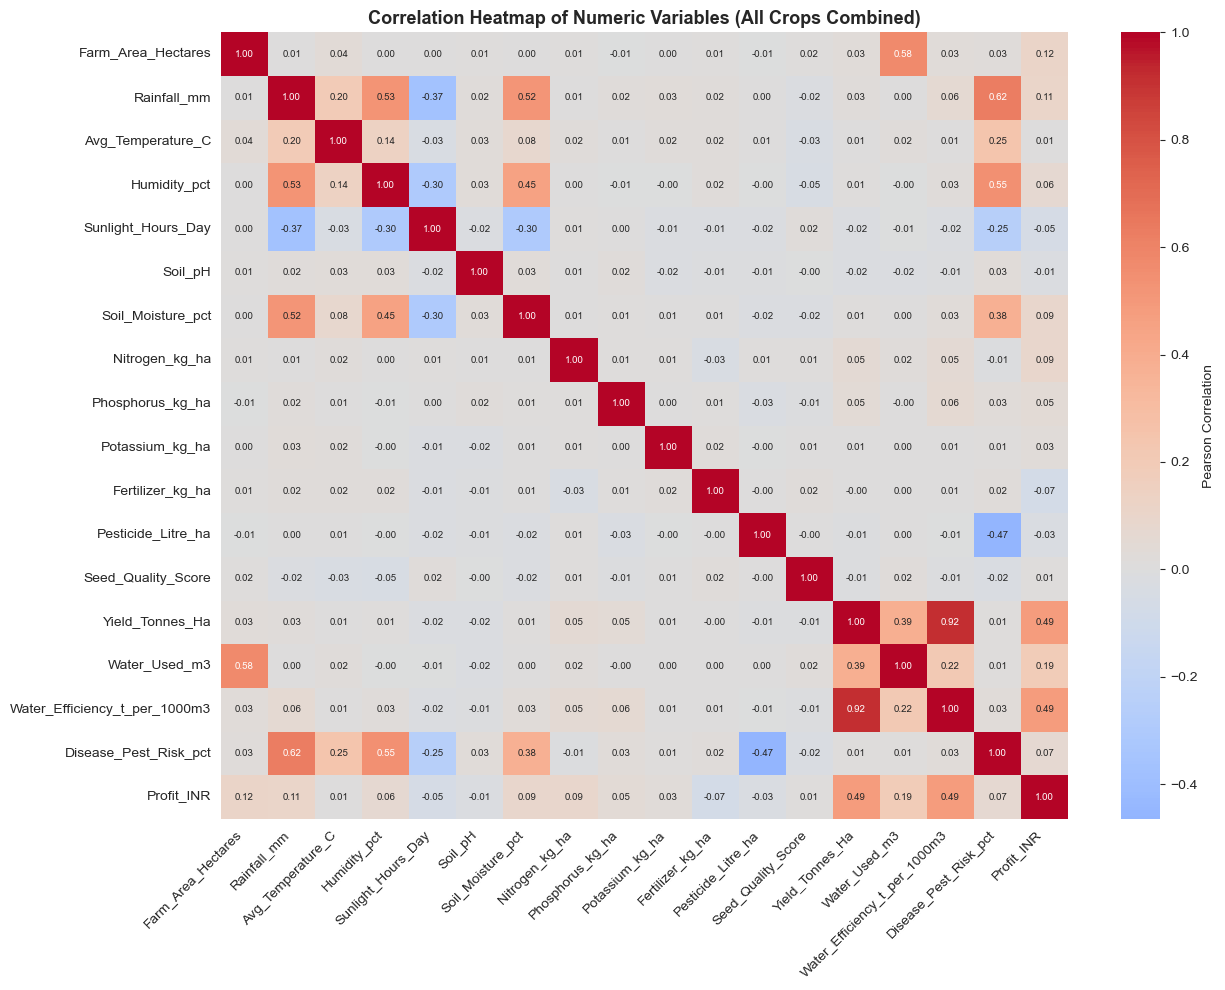

In [42]:
numeric_cols = ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
                'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
                'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha',
                'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Water_Used_m3',
                'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct', 'Profit_INR']

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            annot_kws={'size': 7}, cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Correlation Heatmap of Numeric Variables (All Crops Combined)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [43]:
top_corr_yield = corr_matrix['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(key=abs, ascending=False)
print("Variables most correlated with Yield_Tonnes_Ha (all crops combined):\n")
print(top_corr_yield.round(3))

Variables most correlated with Yield_Tonnes_Ha (all crops combined):

Water_Efficiency_t_per_1000m3    0.916
Profit_INR                       0.489
Water_Used_m3                    0.387
Nitrogen_kg_ha                   0.054
Phosphorus_kg_ha                 0.047
Farm_Area_Hectares               0.031
Rainfall_mm                      0.027
Soil_pH                         -0.022
Sunlight_Hours_Day              -0.015
Disease_Pest_Risk_pct            0.012
Humidity_pct                     0.011
Soil_Moisture_pct                0.010
Avg_Temperature_C                0.009
Pesticide_Litre_ha              -0.009
Seed_Quality_Score              -0.008
Potassium_kg_ha                  0.005
Fertilizer_kg_ha                -0.000
Name: Yield_Tonnes_Ha, dtype: float64


**Interpretation:** Across the *whole, mixed-crop* dataset, correlations between yield and environmental/resource variables are weak — the strongest is `Water_Efficiency_t_per_1000m3` at a moderate level, while rainfall, fertilizer, and pesticide show near-zero correlation with yield. This is because **crop type itself dominates the yield scale** (Sugarcane vs grains), which masks genuine within-crop relationships. Restricting to a single crop, as shown next, reveals the relationships more clearly.

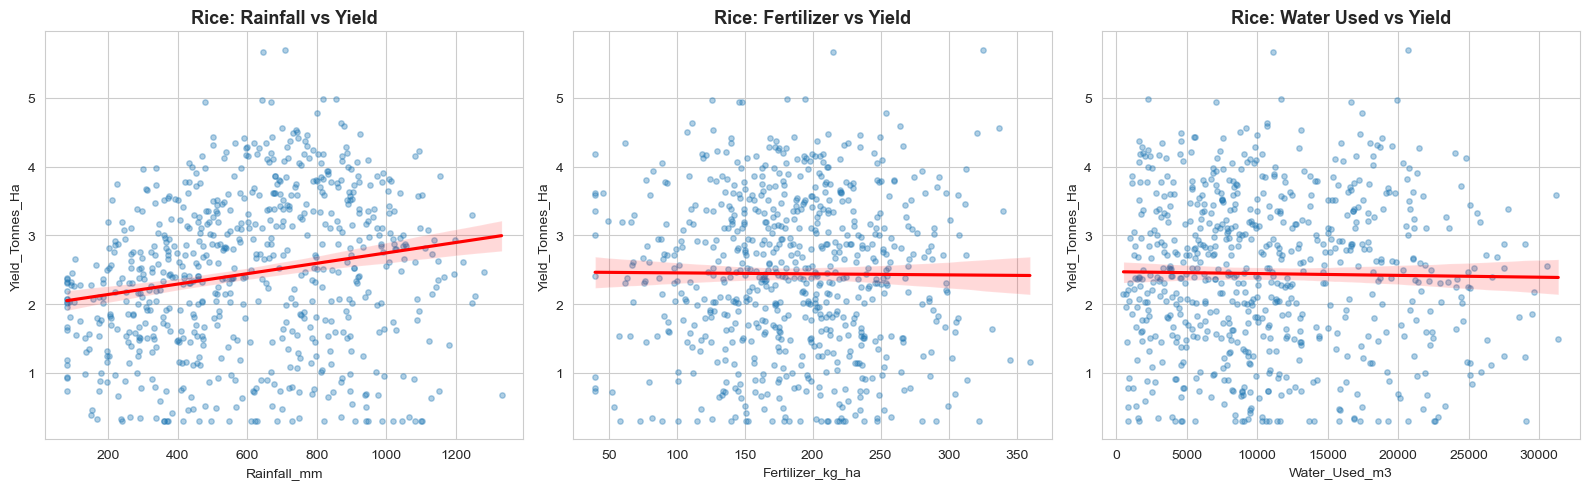

Rice - Rainfall vs Yield:   r = 0.189, p = 5.49e-07
Rice - Fertilizer vs Yield: r = -0.008, p = 8.39e-01
Rice - Water Used vs Yield: r = -0.016, p = 6.71e-01


In [44]:
rice = df[df['Crop'] == 'Rice'].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.regplot(data=rice, x='Rainfall_mm', y='Yield_Tonnes_Ha', ax=axes[0],
            scatter_kws={'alpha': 0.35, 's': 15}, line_kws={'color': 'red'})
axes[0].set_title('Rice: Rainfall vs Yield')

sns.regplot(data=rice, x='Fertilizer_kg_ha', y='Yield_Tonnes_Ha', ax=axes[1],
            scatter_kws={'alpha': 0.35, 's': 15}, line_kws={'color': 'red'})
axes[1].set_title('Rice: Fertilizer vs Yield')

sns.regplot(data=rice, x='Water_Used_m3', y='Yield_Tonnes_Ha', ax=axes[2],
            scatter_kws={'alpha': 0.35, 's': 15}, line_kws={'color': 'red'})
axes[2].set_title('Rice: Water Used vs Yield')

plt.tight_layout()
plt.show()

r_rain, p_rain = stats.pearsonr(rice['Rainfall_mm'], rice['Yield_Tonnes_Ha'])
r_fert, p_fert = stats.pearsonr(rice['Fertilizer_kg_ha'], rice['Yield_Tonnes_Ha'])
r_water, p_water = stats.pearsonr(rice['Water_Used_m3'], rice['Yield_Tonnes_Ha'])

print(f"Rice - Rainfall vs Yield:   r = {r_rain:.3f}, p = {p_rain:.2e}")
print(f"Rice - Fertilizer vs Yield: r = {r_fert:.3f}, p = {p_fert:.2e}")
print(f"Rice - Water Used vs Yield: r = {r_water:.3f}, p = {p_water:.2e}")

**Interpretation:** Within a single crop (Rice), rainfall shows a **weak but statistically significant positive correlation** with yield (r ≈ 0.19, p < 0.001), while fertilizer and water used show **no significant linear relationship** with yield in this dataset. This is an important, non-obvious finding — it suggests yield differences are not simply a matter of "more input = more output" once crop type is held constant, and that other factors (seed quality, disease/pest risk, soil condition) likely matter more.

## Statistical Analysis

Three targeted statistical tests are used to confirm (rather than just visually suggest) the seasonal patterns found above:

1. **One-way ANOVA** — is the difference in Rice yield across the three seasons statistically significant?
2. **One-way ANOVA** — is the difference in Rice profit across the three seasons statistically significant?
3. **Chi-square test of independence** — is the choice of irrigation method associated with season, or independent of it?

Rice is used to control for crop type, since it is the only crop with substantial representation in all three seasons (314 Kharif, 274 Rabi, 102 Zaid records).

In [45]:
groups_yield = [rice.loc[rice['Season'] == s, 'Yield_Tonnes_Ha'] for s in season_order]
f_stat, p_value = stats.f_oneway(*groups_yield)

print("One-Way ANOVA: Rice Yield across Season")
print(f"F-statistic = {f_stat:.3f}, p-value = {p_value:.3e}")
print("Result:", "Statistically significant difference (reject H0)" if p_value < 0.05
      else "No statistically significant difference")

One-Way ANOVA: Rice Yield across Season
F-statistic = 22.632, p-value = 3.028e-10
Result: Statistically significant difference (reject H0)


In [46]:
groups_profit = [rice.loc[rice['Season'] == s, 'Profit_INR'] for s in season_order]
f_stat2, p_value2 = stats.f_oneway(*groups_profit)

print("One-Way ANOVA: Rice Profit across Season")
print(f"F-statistic = {f_stat2:.3f}, p-value = {p_value2:.3e}")
print("Result:", "Statistically significant difference (reject H0)" if p_value2 < 0.05
      else "No statistically significant difference")

One-Way ANOVA: Rice Profit across Season
F-statistic = 16.404, p-value = 1.098e-07
Result: Statistically significant difference (reject H0)


In [47]:
contingency = pd.crosstab(df['Season'], df['Irrigation_Method'])
chi2, chi_p, dof, expected = stats.chi2_contingency(contingency)

print("Chi-Square Test of Independence: Irrigation Method vs Season")
print(contingency)
print(f"\nChi2 statistic = {chi2:.3f}, degrees of freedom = {dof}, p-value = {chi_p:.3f}")
print("Result:", "Irrigation method is significantly associated with season (reject H0)" if chi_p < 0.05
      else "No significant association — irrigation method choice is independent of season")

Chi-Square Test of Independence: Irrigation Method vs Season
Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif              405    590      463        321
Rabi                370    526      438        293
Zaid                140    194      140        120

Chi2 statistic = 3.513, degrees of freedom = 6, p-value = 0.742
Result: No significant association — irrigation method choice is independent of season


**Interpretation of statistical results:**

- Both ANOVA tests return **p-values far below 0.05**, confirming that the differences in Rice yield and Rice profit across Kharif, Rabi, and Zaid seen in the charts are **statistically significant**, not random noise.
- The Chi-square test returns **p ≈ 0.74 (> 0.05)**, meaning irrigation method choice is **not** significantly associated with season — farmers in this dataset use roughly the same mix of irrigation methods regardless of season, even though Zaid is hotter and drier. This is flagged as an unusual/unexpected pattern in the Insights section.

## Key Data-Driven Insights

1. **Kharif consistently outperforms Rabi and Zaid in yield.** Excluding Sugarcane, median yield falls from 1.95 t/ha (Kharif) to 1.66 t/ha (Rabi) to 1.45 t/ha (Zaid) — a pattern confirmed as statistically significant by ANOVA on Rice (p < 0.001).

2. **Profitability follows the same seasonal order and is even more extreme.** Kharif is the only season with a positive median profit (~₹38,800); Rabi and Zaid both show negative median profit, and the share of loss-making farms rises steadily from 42.2% (Kharif) to 51.1% (Rabi) to **64.5% (Zaid)**.

3. **The dataset's environmental readings are agronomically realistic.** Kharif shows the highest rainfall/humidity (monsoon), Zaid shows the highest temperature and lowest rainfall (hot/dry summer), and Rabi is the coolest season — validating that the seasonal labels reflect genuine, distinguishable conditions rather than arbitrary tags.

4. **Zaid farms use more water despite lower rainfall, but with lower water efficiency.** This suggests irrigation is compensating for the dry season, but not efficiently enough to preserve yield or profit.

5. **Market price is not the driver of seasonal profit differences.** Average market price per tonne is similar across seasons, so the profit gap traces back to **yield and cost differences**, not to farmers selling at worse prices in weaker seasons.

6. **The seasonal yield pattern generalizes across states**, not just in aggregate — Kharif yield exceeds Zaid yield in almost every one of the eight states studied, though median profit still varies meaningfully by state, indicating regional factors operate alongside seasonal ones.

7. **Correlations behave differently once crop type is controlled for.** Across the whole mixed-crop dataset, rainfall/fertilizer/water show almost no correlation with yield — but within Rice alone, rainfall has a weak, statistically significant positive relationship with yield (r ≈ 0.19, p < 0.001), while fertilizer and water usage show no significant linear relationship. **Unexpected finding:** more fertilizer or more water does not, by itself, predict higher yield in this data.

8. **Irrigation method choice does not vary meaningfully by season** (Chi-square p ≈ 0.74) — an unexpected pattern, since Zaid's hot/dry conditions might be expected to push farmers toward more Drip or Sprinkler irrigation and away from Rainfed farming, but the data shows no such shift.

## Recommendations

1. **Re-evaluate Zaid-season cultivation choices.** With nearly two-thirds of Zaid farms operating at a loss and yields ~25% below Kharif, agricultural planners and farmers should reassess which crops are viable in Zaid, or whether some Zaid land is better left fallow, rotated, or switched to lower-water-demand crops.

2. **Prioritize water-use efficiency programs in Zaid specifically.** Since Zaid already uses more water than other seasons but produces the lowest water efficiency, targeted efficient-irrigation investment (e.g., drip conversion, scheduling) in this season is likely to yield a better return than blanket seasonal investment.

3. **Do not treat fertilizer/water increases as a default lever for higher yield.** Since within-crop correlations between fertilizer, water use, and yield are weak or non-significant, blanket increases in these inputs are unlikely to reliably raise yield — instead, factors such as seed quality and disease/pest risk warrant closer investigation as potential higher-leverage targets.

4. **Investigate why irrigation method doesn't shift with season.** Given that Zaid's dry conditions do not correspond to greater use of efficient irrigation methods, extension programs could specifically encourage a shift toward Drip/Sprinkler irrigation for Zaid-season farms.

5. **Combine seasonal and state-level planning.** Because profitability varies by state even after accounting for season, seasonal recommendations should be tailored per state/region rather than applied uniformly nationwide.

6. **Use Kharif's success factors as a benchmark.** Since Kharif shows both the best yield and the best profitability, understanding what specifically differs in Kharif farming practice (beyond just rainfall) could help transfer some of that advantage to Rabi and Zaid.

## Final Conclusion

This analysis of 4,000 farm records across eight states, eight crops, and three seasons confirms that **season is a strong and statistically significant driver of agricultural performance** in this dataset. Kharif consistently delivers the best yield and the only positive median profit, while Zaid — despite heavier irrigation — delivers the lowest yield and the highest rate of loss-making farms. Environmental readings validate that these seasons represent genuinely distinct growing conditions (rainfall, temperature, humidity), and the seasonal yield advantage of Kharif holds broadly across states rather than being a regional artifact.

At the same time, the analysis surfaces two genuinely **evidence-based, non-obvious findings**: (1) resource inputs like fertilizer and water show little to no direct correlation with yield once crop type is controlled for, cautioning against assuming "more input equals more output," and (2) irrigation method choice does not adapt to season despite Zaid's harsher, drier conditions — a planning gap worth addressing.

Overall, the findings support **evidence-based, season-aware agricultural planning**: prioritizing water-efficiency and crop-suitability decisions in Zaid, benchmarking Kharif's practices, and tailoring interventions by both season and state rather than applying one-size-fits-all policy.